In [1]:
import torch
import pickle
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import random_split

In [2]:
#defining Model
class Model(nn.Module):

    def __init__(self):
      super().__init__()

      self.firstBranch=nn.Sequential(
          nn.Linear(784,16),
          nn.ReLU()
      )

      self.branch1=nn.Sequential(
          nn.Linear(16,12),
          nn.ReLU(),
          nn.Linear(12,8),
          nn.ReLU()
      )

      self.branch2=nn.Sequential(
          nn.Linear(16,8),
          nn.ReLU(),
          nn.Linear(8,8),
          nn.ReLU()
      )

      self.output=nn.Linear(16,10)

    
    def forward(self,x):
      #flattening step
      x = x.view(x.shape[0],-1)
      
      x1=self.firstBranch(x)
      x2=self.branch1(x1)
      x3=self.branch2(x1)
      
      merged=torch.cat((x2,x3),dim=1)

      logits=self.output(merged)

      return logits

In [3]:
#Loading Datasets

train = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

train_size = int(0.8*(len(train)))
val_size = int(len(train)-train_size)

#splitting dataset for train and validation
train_dataset, val_dataset = random_split(train, [train_size, val_size])

In [4]:
#now we want load datasets via dataloader

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)

val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=True)

In [5]:
model = Model()

In [6]:
epochs=20

loss_history=[]
accuracy_history=[]

crieterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, verbose=True, mode="min", patience=3, factor=0.5)


for _ in range(epochs):
    count=0
    total=0
    
    for img, labels in train_dataloader:
        optimizer.zero_grad()
    
        output = model(img)
    
        loss = crieterion(output, labels)

        _,pred=torch.max(output,1)
        count+=(pred==labels).sum().item()
        total+=labels.size(0)
    
        loss.backward()
    
        optimizer.step()
    
        #accuracy 
        accuracy=count/total

    #using scheduller to maintain good lr 
    scheduler.step(loss)
    
    loss_history.append(loss.item())
    accuracy_history.append(accuracy)

C:\Users\0yash\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [7]:
loss_history

[0.4071027636528015,
 0.34396153688430786,
 0.555030107498169,
 0.6793850064277649,
 0.4283328652381897,
 0.3975610136985779,
 0.36644142866134644,
 0.4792596697807312,
 0.39095672965049744,
 0.4112463891506195,
 0.32295143604278564,
 0.3948684334754944,
 0.2747114300727844,
 0.38835200667381287,
 0.18741561472415924,
 0.3633526563644409,
 0.23750083148479462,
 0.39775627851486206,
 0.3139585852622986,
 0.37017396092414856]

In [8]:
accuracy

0.87225

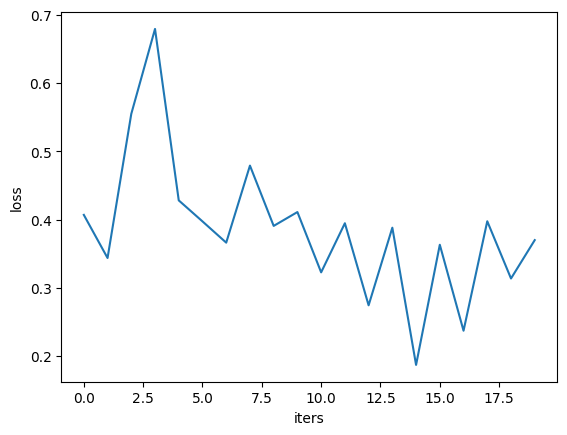

In [9]:
plt.plot(loss_history)
plt.xlabel("iters")
plt.ylabel("loss")
plt.show()

In [10]:
with open("fashion_model.pkl", "wb") as f:
    pickle.dump(model.state_dict(),f)
    

In [11]:
with open("fashion_model.pkl", "rb") as f:
    weights = pickle.load(f)

model.load_state_dict(weights)

<All keys matched successfully>

<function matplotlib.pyplot.show(close=None, block=None)>

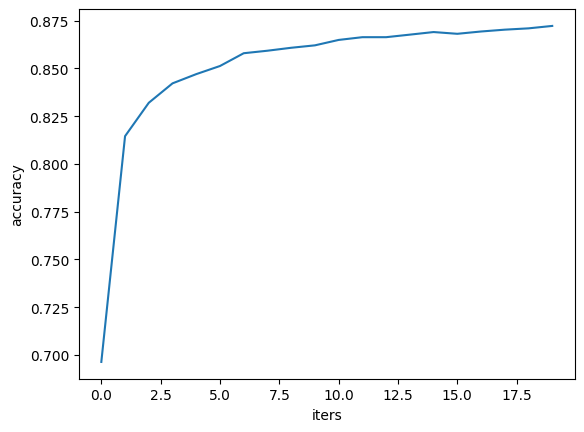

In [12]:
plt.plot(accuracy_history)
plt.xlabel("iters")
plt.ylabel("accuracy")
plt.show

**testing trained model on validation set** 

In [14]:
count=0
total=0
for img, labels in val_dataloader:
    output=model(img)

    loss=crieterion(output, labels)

    _,pred=torch.max(output,1)
    count+=(pred==labels).sum().item()
    total+=labels.size(0)

    accuracy=count/total

In [15]:
accuracy

0.85975

In [16]:
loss

tensor(0.4665, grad_fn=<NllLossBackward0>)